In [1]:
from data.dataset import FilteredHiRISEDataset, HiRISEDataset
import pandas as pd
import os, time 
from pathlib import Path

project_root = str(Path.cwd())
project_root


'd:\\Imperial\\IRP\\HiRISE_diffusion'

In [2]:
dr = pd.read_csv(project_root + '\\data\\files\\data_record_bin12.csv')
allowed_sets = [19645, 7292, 7293, 14774]  # observations present in data/files/npy_files_b12

dataset = FilteredHiRISEDataset(transform=None, data_record=dr, meta_cols=['Binning', 'TDI'], sweep=False, allowed_sets=allowed_sets)

start_time = time.time()
print(f"Dataset initialisation time: {time.time() - start_time:.2f} seconds")

Filtered dataset:
	Observations: 3
	Sets: 4
	Images: 20
	Proportion of sets: 0.02%

Dataset initialisation time: 0.00 seconds


In [3]:
sample = dataset[1]
print(sample.keys())

dict_keys(['x_band', 'x_neigh', 'x_meta', 'y', 'stats', 'chan_spec_band', 'chan_spec_neigh', 'meta_spec', 'obs_id', 'set_name', 'date'])


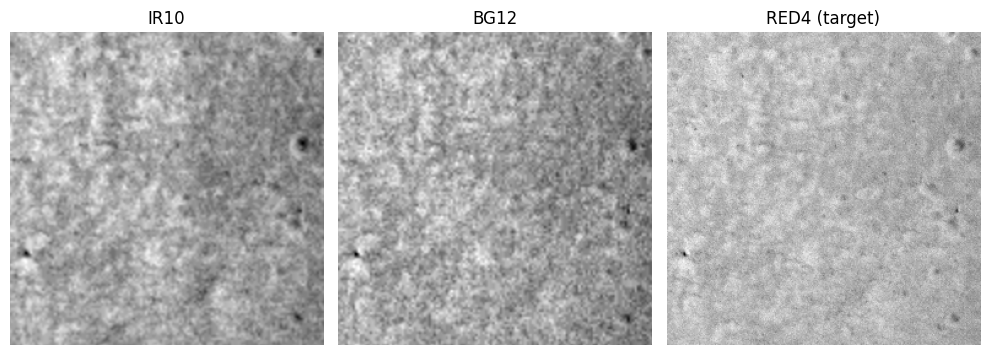

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(10, 5))

axs[0].imshow(sample['x_band'][0].numpy(), cmap='gray')
axs[0].set_title("IR10")
axs[0].axis('off')
axs[1].imshow(sample['x_band'][1].numpy(), cmap='gray')
axs[1].set_title("BG12")
axs[1].axis('off')
axs[2].imshow(sample['y'][0].numpy(), cmap='gray')
axs[2].set_title("RED4 (target)")
axs[2].axis('off')
plt.tight_layout()
plt.show()

In [5]:
import sys
import torch
import numpy as np
sys.path.insert(0, os.path.join(project_root, "src"))

from config import ModelConfig, InferenceConfig
from models.cm_diff_unet import UNet
from diffusion.scheduler import DDPMScheduler
from compute_prior import load_prior_stats
from inference import sample

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cfg_model = ModelConfig()
cfg_inf   = InferenceConfig()

model = UNet(
    in_channels   = cfg_model.in_channels,
    out_channels  = cfg_model.out_channels,
    base_channels = cfg_model.base_channels,
    num_res_blocks= cfg_model.num_res_blocks,
    dropout       = cfg_model.dropout,
).to(device)

ckpt = torch.load(os.path.join(project_root, "src/output/latest.pt"), map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()
print(f"Loaded checkpoint  step={ckpt.get('step','?')}  loss={ckpt.get('loss','?'):.4f}")

scheduler = DDPMScheduler(
    timesteps  = cfg_model.timesteps,
    beta_start = cfg_model.beta_start,
    beta_end   = cfg_model.beta_end,
).to(device)

prior_stats = load_prior_stats(os.path.join(project_root, "src/output/prior_red.pt"), device)
print(f"Prior: mu={prior_stats['mu'].item():.4f}  sigma={prior_stats['sigma'].item():.4f}")

Loaded checkpoint  step=100000  loss=0.0673
Prior: mu=4.0438  sigma=6.0646


In [6]:
# Pick a sample from DiffusionDataset for inference
from data.dataset import DiffusionDataset
diff_dataset = DiffusionDataset(
    data_record=dr, data_root=project_root + "/data", sweep=True,
    allowed_sets=allowed_sets,
)

SAMPLE_IDX = 0   # change to try different samples
diff_sample = diff_dataset[SAMPLE_IDX]

# ir: (1,H,W) already normalised by joint IR+BG stats
ir_tensor  = diff_sample["ir"].unsqueeze(0).to(device)   # (1,1,H,W)
red_gt     = diff_sample["red"].squeeze().cpu().numpy()   # (H,W)
ir_display = diff_sample["ir"].squeeze().cpu().numpy()    # (H,W)

print(f"obs={diff_sample['obs_id']}  set={diff_sample['set_name']}")
print(f"IR  range=[{ir_display.min():.3f}, {ir_display.max():.3f}]")
print(f"GT  range=[{red_gt.min():.3f}, {red_gt.max():.3f}]")

# Run inference (direction=0: IR→RED)
with torch.no_grad():
    pred = sample(model, scheduler, ir_tensor, direction=0,
                  prior_stats=prior_stats, cfg_inf=cfg_inf, device=device)

red_pred = pred.squeeze().cpu().numpy()   # (H,W)
print(f"Pred range=[{red_pred.min():.3f}, {red_pred.max():.3f}]")

obs=ESP_058229_1830  set=7292
IR  range=[14.577, 16.763]
GT  range=[10.391, 13.676]
[init] sqrt_ab_T=0.0064  x_source mean=15.7572  x_T mean≈0.1001
  t= 900  x range=[-4.290, 4.537]
  t= 800  x range=[-3.253, 4.837]
  t= 700  x range=[-2.860, 5.471]
  t= 600  x range=[-1.608, 6.387]
  t= 500  x range=[0.230, 8.832]
  t= 400  x range=[2.495, 10.853]
  t= 300  x range=[6.345, 12.904]
  t= 200  x range=[9.357, 14.882]
  t= 100  x range=[12.667, 15.941]
  t=   0  x range=[13.344, 16.299]
Pred range=[13.344, 16.299]


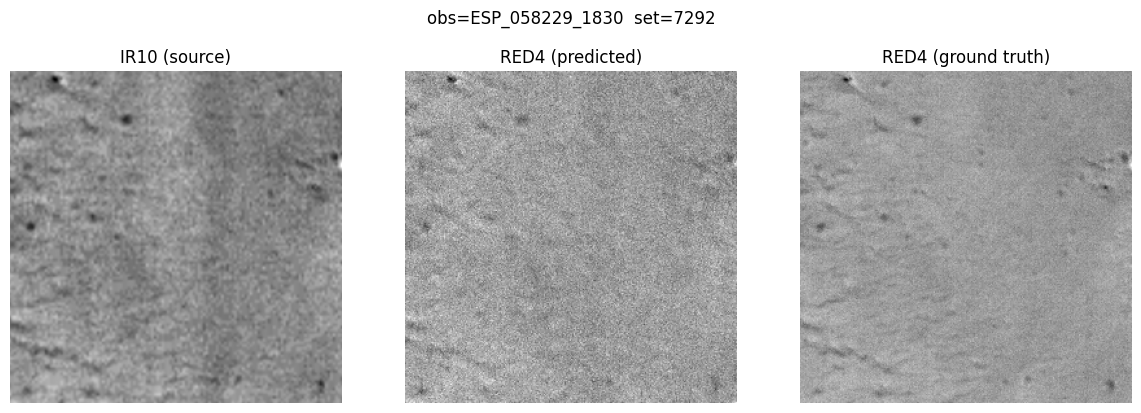

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(ir_display, cmap="gray")
axs[0].set_title("IR10 (source)")
axs[0].axis("off")

axs[1].imshow(red_pred, cmap="gray")
axs[1].set_title("RED4 (predicted)")
axs[1].axis("off")

axs[2].imshow(red_gt, cmap="gray")
axs[2].set_title("RED4 (ground truth)")
axs[2].axis("off")

plt.suptitle(f"obs={diff_sample['obs_id']}  set={diff_sample['set_name']}", y=1.02)
plt.tight_layout()
plt.show()

In [27]:
# Run inference for each lambda value with a fixed seed for fair comparison
lambdas = np.linspace(100, 1000, num=11).astype(np.int32).tolist()  # 7 values from 30 to 100
# lambdas = [30, 40, 50, 60, 70, 80, 90, 100]  # --- IGNORE ---
sci_predictions = {}
SEED = 42

for lam in lambdas:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed(SEED)
    cfg = InferenceConfig(lambda_scl=float(lam), lambda_ccl=float(lam))
    with torch.no_grad():
        pred = sample(model, scheduler, ir_tensor, direction=0,
                      prior_stats=prior_stats, cfg_inf=cfg, device=device)
    sci_predictions[lam] = pred.squeeze().cpu().numpy()
    print(f"λ={lam:2d}  range=[{sci_predictions[lam].min():.3f}, {sci_predictions[lam].max():.3f}]  mean={sci_predictions[lam].mean():.3f}")

[init] sqrt_ab_T=0.0064  x_source mean=15.7572  x_T mean≈0.1001
  t= 900  x range=[-4.743, 4.447]
  t= 800  x range=[-3.800, 4.932]
  t= 700  x range=[-2.623, 5.142]
  t= 600  x range=[-1.864, 7.557]
  t= 500  x range=[-0.153, 7.779]
  t= 400  x range=[2.780, 10.576]
  t= 300  x range=[6.125, 12.212]
  t= 200  x range=[9.566, 14.315]
  t= 100  x range=[12.111, 15.538]
  t=   0  x range=[13.276, 15.823]
λ=100  range=[13.276, 15.823]  mean=14.658
[init] sqrt_ab_T=0.0064  x_source mean=15.7572  x_T mean≈0.1001
  t= 900  x range=[-4.737, 4.434]
  t= 800  x range=[-3.799, 4.895]
  t= 700  x range=[-2.632, 5.078]
  t= 600  x range=[-1.909, 7.454]
  t= 500  x range=[-0.235, 7.609]
  t= 400  x range=[2.618, 10.353]
  t= 300  x range=[5.881, 11.903]
  t= 200  x range=[9.241, 13.934]
  t= 100  x range=[11.723, 15.095]
  t=   0  x range=[12.858, 15.375]
λ=190  range=[12.858, 15.375]  mean=14.223
[init] sqrt_ab_T=0.0064  x_source mean=15.7572  x_T mean≈0.1001
  t= 900  x range=[-4.730, 4.419]
  t=

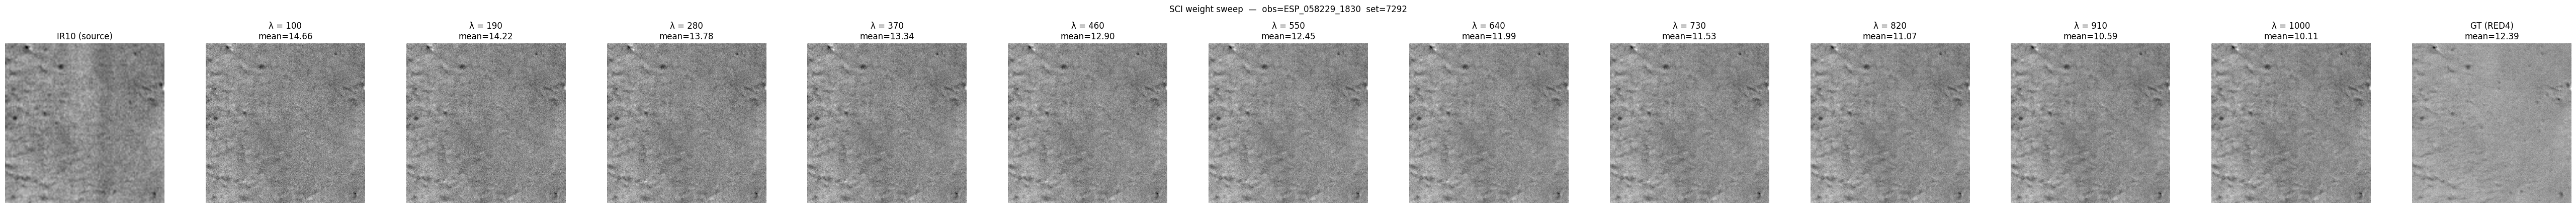

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

n_pred = len(lambdas)
fig, axs = plt.subplots(1, n_pred + 2, figsize=(4 * (n_pred + 2), 4))

axs[0].imshow(ir_display, cmap="gray")
axs[0].set_title("IR10 (source)")
axs[0].axis("off")

for i, lam in enumerate(lambdas):
    axs[i + 1].imshow(sci_predictions[lam], cmap="gray")
    mean_val = sci_predictions[lam].mean()
    axs[i + 1].set_title(f"λ = {lam}\nmean={mean_val:.2f}")
    axs[i + 1].axis("off")

axs[-1].imshow(red_gt, cmap="gray")
axs[-1].set_title(f"GT (RED4)\nmean={red_gt.mean():.2f}")
axs[-1].axis("off")

plt.suptitle(f"SCI weight sweep  —  obs={diff_sample['obs_id']}  set={diff_sample['set_name']}", y=1.02)
plt.tight_layout()
plt.show()

λ=100  MSE=5.2093
λ=190  MSE=3.4182
λ=280  MSE=1.9981
λ=370  MSE=0.9563
λ=460  MSE=0.3009
λ=550  MSE=0.0407
λ=640  MSE=0.1888
λ=730  MSE=0.7593
λ=820  MSE=1.7710
λ=910  MSE=3.2459
λ=1000  MSE=5.1993

Best λ = 550  (MSE=0.0407)


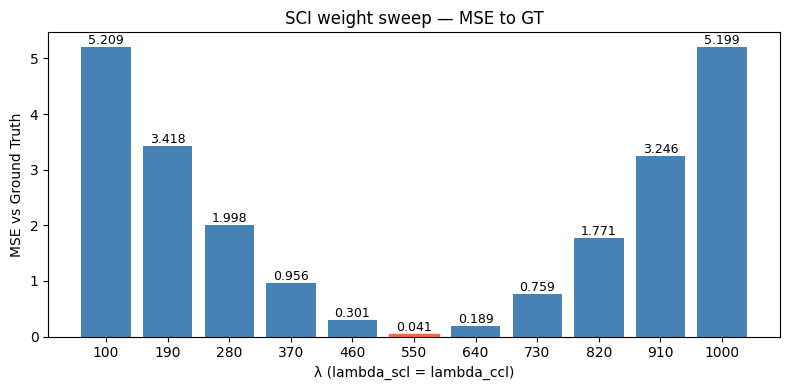

In [29]:
import numpy as np
import matplotlib.pyplot as plt

gt_t = torch.from_numpy(red_gt)
mse_scores = {}
for lam in lambdas:
    pred_t = torch.from_numpy(sci_predictions[lam])
    mse_scores[lam] = torch.nn.functional.mse_loss(pred_t, gt_t).item()
    print(f"λ={lam:2d}  MSE={mse_scores[lam]:.4f}")

best_lam = min(mse_scores, key=mse_scores.get)
print(f"\nBest λ = {best_lam}  (MSE={mse_scores[best_lam]:.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar([str(l) for l in lambdas], list(mse_scores.values()), color="steelblue")
bars[lambdas.index(best_lam)].set_color("tomato")
ax.set_xlabel("λ (lambda_scl = lambda_ccl)")
ax.set_ylabel("MSE vs Ground Truth")
ax.set_title("SCI weight sweep — MSE to GT")
for bar, val in zip(bars, mse_scores.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()